# 3.2. Проверка гипотез с помощью корреляционного и кластерного анализа

В параграфе 3.2 вакансии сначала делятся на профессиональные кластеры, а затем внутри этих кластеров проверяется связь заработной платы с факторами из гипотез: техническими навыками, опытом, регионом и форматом работы.

## Алгоритм выполнения параграфа 3.2

1. Загрузить рабочую выборку вакансий с зарплатой в рублях.
2. Сформировать пять профессиональных кластеров по специальностям.
3. Обосновать объединение продуктовой аналитики с аналитикой данных из-за малого числа продуктовых вакансий и близости требований.
4. Рассчитать численность, зарплатные характеристики и частые навыки по каждому кластеру.
5. Проверить нормальность `salary_mid` внутри каждого кластера на уровне значимости 0,05.
6. Построить диаграмму связи `salary_mid` с уровнем опыта внутри кластеров. Опыт является порядковым признаком, поэтому график используется как предварительная визуальная проверка направления связи.
7. Не использовать Пирсона для проверки гипотез, так как в данных нет независимых непрерывных количественных факторов зарплаты.
8. Основную проверку гипотез выполнить через Спирмена между `salary_mid` и признаками навыков, опыта, региона и формата работы.
9. Построить тепловые карты Спирмена по факторам гипотез внутри кластеров.
10. Сформировать итоговую таблицу проверки H1-H4.

## 1. Подключение библиотек и загрузка данных

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

DATA_PATH = Path('../data/processed/vacancies_for_model_final.csv')
FIG_DIR = Path('figures_3_2')
FIG_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PATH)

# Используем ту же рабочую выборку, что и в параграфе 3.1.
df = df[(df['salary_mid'] >= 20_000) & (df['salary_mid'] <= 800_000)].copy()
print('Размер рабочей выборки:', df.shape)
df.head()

Размер рабочей выборки: (686, 41)


,vacancy_id,name,alternate_url,employer_name,area_name,city_group,experience_name,schedule_name,employment_name,salary_from,salary_to,salary_currency,salary_gross,has_salary,salary_mid,key_skills,description_text,primary_role,is_business_analyst,is_system_analyst,is_bi_analyst,is_data_analyst,is_product_analyst,is_ds_ml,has_sql,has_python,has_excel,has_power_bi,has_tableau,has_bi_tools,has_dwh,has_etl,has_ml,has_statistics,has_ab_testing,has_bpmn,has_uml,has_api,has_requirements,has_1c,has_jira
0,133289938,Junior Бизнес-аналитик,https://hh.ru/vacancy/133289938,Metacommerce,Казань,Регионы,От 1 года до 3 лет,Удалённо,Полная,80000.0,120000.0,RUR,False,1,100000.0,"Бизнес-анализ, Power BI, SQL, Управление ожида...",Развиваем собственный IT-продукт для работы с ...,Business Analytics,1,0,0,0,0,0,1,0,1,1,0,1,0,0,0,0,0,1,0,1,0,0,0
1,133169592,Бизнес-аналитик,https://hh.ru/vacancy/133169592,РамСар,Казань,Регионы,От 1 года до 3 лет,На месте работодателя,Полная,150000.0,NaN,RUR,True,1,150000.0,NaN,Чем предстоит заниматься: Проведение комплексн...,Business Analytics,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,133069549,Бизнес-аналитик,https://hh.ru/vacancy/133069549,Нэфис Косметикс,Казань,Регионы,От 1 года до 3 лет,На месте работодателя,Полная,100000.0,NaN,RUR,True,1,100000.0,"Альт-Инвест, Планирование, Аналитическое мышле...","АО ""Нэфис Косметикс"" - динамично развивающаяся...",Business Analytics,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0
3,133085193,Бизнес-аналитик 1С:ERP по РСБУ,https://hh.ru/vacancy/133085193,Агросила,Казань,Регионы,От 1 года до 3 лет,"На месте работодателя, Удалённо, Гибрид",Полная,140000.0,150000.0,RUR,True,1,145000.0,NaN,В связи с созданием проекта по внедрению 1С:ER...,Business Analytics,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0
4,133054530,Бизнес/Системный аналитик (1С-Битрикс),https://hh.ru/vacancy/133054530,Ай-Пласт,Казань,Регионы,От 3 до 6 лет,Удалённо,Полная,190000.0,NaN,RUR,False,1,190000.0,"Бизнес-анализ, Системный анализ, BPMN, BABOK, ...",Plast— лидер рынка переработки полимеров и про...,System Analytics,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,1,1,1,1,1,1


## 2. Формирование профессиональных кластеров

In [2]:
role_names = {
    'Business Analytics': 'Бизнес-аналитика',
    'System Analytics': 'Системная аналитика',
    'BI/DWH Analytics': 'BI/DWH-аналитика',
    'Data Analytics': 'Аналитика данных',
    'Product Analytics': 'Продуктовая аналитика',
    'DS/ML Analytics': 'DS/ML',
}

cluster_map = {
    'Business Analytics': 'Бизнес-аналитика',
    'BI/DWH Analytics': 'BI/DWH-аналитика',
    'Data Analytics': 'Аналитика данных и продуктовая аналитика',
    'Product Analytics': 'Аналитика данных и продуктовая аналитика',
    'System Analytics': 'Системная аналитика',
    'DS/ML Analytics': 'DS/ML',
}

cluster_order = [
    'Бизнес-аналитика',
    'BI/DWH-аналитика',
    'Аналитика данных и продуктовая аналитика',
    'Системная аналитика',
    'DS/ML',
]

df['Направление'] = df['primary_role'].map(role_names).fillna(df['primary_role'])
df['cluster_name'] = df['primary_role'].map(cluster_map)
df = df[df['cluster_name'].notna()].copy()
df['cluster_name'] = pd.Categorical(df['cluster_name'], categories=cluster_order, ordered=True)
df['cluster_id'] = df['cluster_name'].cat.codes + 1

cluster_counts = (
    df.groupby(['cluster_id', 'cluster_name'], observed=True)
    .size()
    .reset_index(name='Количество вакансий')
)
cluster_counts['Доля, %'] = (cluster_counts['Количество вакансий'] / len(df) * 100).round(2)
cluster_counts

,cluster_id,cluster_name,Количество вакансий,"Доля, %"
0,1,Бизнес-аналитика,168,24.49
1,2,BI/DWH-аналитика,68,9.91
2,3,Аналитика данных и продуктовая аналитика,132,19.24
3,4,Системная аналитика,248,36.15
4,5,DS/ML,70,10.20


## 3. Обоснование объединения аналитики данных и продуктовой аналитики

In [3]:
role_counts = (
    df['Направление']
    .value_counts()
    .reindex(['Бизнес-аналитика', 'BI/DWH-аналитика', 'Аналитика данных', 'Продуктовая аналитика', 'Системная аналитика', 'DS/ML'])
    .reset_index()
)
role_counts.columns = ['Направление', 'Количество вакансий']
role_counts['Доля, %'] = (role_counts['Количество вакансий'] / len(df) * 100).round(2)
role_counts

,Направление,Количество вакансий,"Доля, %"
0,Бизнес-аналитика,168,24.49
1,BI/DWH-аналитика,68,9.91
2,Аналитика данных,106,15.45
3,Продуктовая аналитика,26,3.79
4,Системная аналитика,248,36.15
5,DS/ML,70,10.20


Продуктовая аналитика объединена с аналитикой данных, поскольку в выборке она представлена небольшим числом вакансий, а по содержанию требований близка к аналитике данных.

## 4. Зарплатные характеристики по кластерам

In [4]:
cluster_salary = (
    df.groupby(['cluster_id', 'cluster_name'], observed=True)['salary_mid']
    .agg(['count', 'mean', 'median', 'min', 'max', 'std'])
    .reset_index()
)
cluster_salary.columns = [
    'Кластер', 'Название кластера', 'Количество', 'Среднее', 'Медиана', 'Минимум', 'Максимум', 'Стандартное отклонение'
]
for col in ['Среднее', 'Медиана', 'Минимум', 'Максимум', 'Стандартное отклонение']:
    cluster_salary[col] = cluster_salary[col].round(2)
cluster_salary

,Кластер,Название кластера,Количество,Среднее,Медиана,Минимум,Максимум,Стандартное отклонение
0,1,Бизнес-аналитика,168,151471.73,140000.0,40000.0,350000.0,71627.92
1,2,BI/DWH-аналитика,68,163778.66,149712.5,25000.0,400000.0,77708.17
2,3,Аналитика данных и продуктовая аналитика,132,144863.48,130000.0,30000.0,500000.0,80541.48
3,4,Системная аналитика,248,182024.61,182000.0,30000.0,500000.0,92372.89
4,5,DS/ML,70,241639.86,200000.0,80000.0,700000.0,116501.67


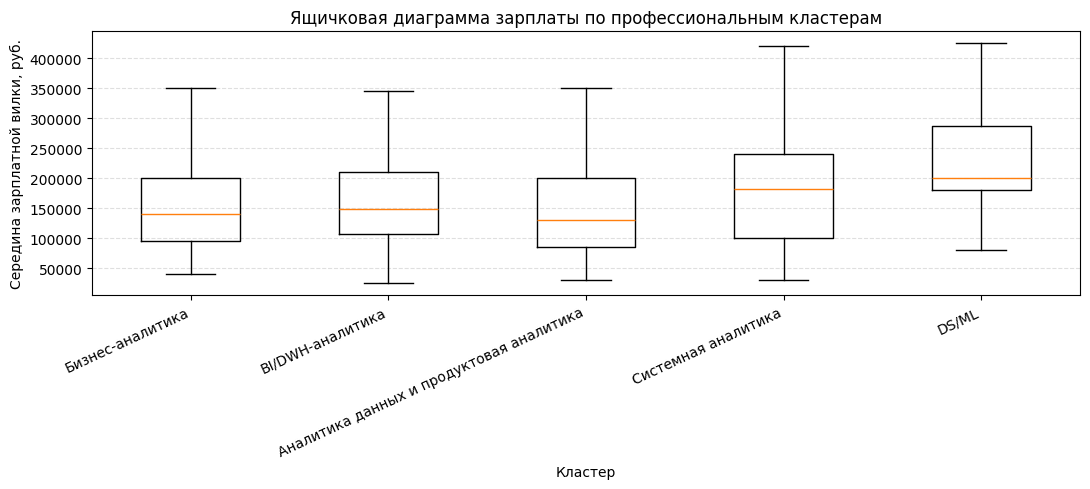

In [5]:
groups = []
labels = []
for cluster_name in cluster_order:
    group = df[df['cluster_name'] == cluster_name]
    groups.append(group['salary_mid'])
    labels.append(cluster_name)

plt.figure(figsize=(11, 5))
plt.boxplot(groups, tick_labels=labels, showfliers=False)
plt.title('Ящичковая диаграмма зарплаты по профессиональным кластерам')
plt.xlabel('Кластер')
plt.ylabel('Середина зарплатной вилки, руб.')
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_3_2_1_salary_by_professional_cluster.png', dpi=200)
plt.show()

## 5. Характерные навыки по кластерам

In [6]:
skill_columns = [
    'has_sql', 'has_python', 'has_power_bi', 'has_tableau', 'has_bi_tools',
    'has_dwh', 'has_etl', 'has_ml', 'has_statistics', 'has_ab_testing',
    'has_bpmn', 'has_uml', 'has_api', 'has_requirements', 'has_1c', 'has_jira'
]

skill_names = {
    'has_sql': 'SQL',
    'has_python': 'Python',
    'has_power_bi': 'Power BI',
    'has_tableau': 'Tableau',
    'has_bi_tools': 'BI-инструменты',
    'has_dwh': 'DWH',
    'has_etl': 'ETL',
    'has_ml': 'ML',
    'has_statistics': 'Статистика',
    'has_ab_testing': 'A/B-тестирование',
    'has_bpmn': 'BPMN',
    'has_uml': 'UML',
    'has_api': 'API',
    'has_requirements': 'Требования / ТЗ',
    'has_1c': '1C',
    'has_jira': 'Jira / Confluence',
}

top_skills_rows = []
for cluster_name in cluster_order:
    group = df[df['cluster_name'] == cluster_name]
    shares = group[skill_columns].fillna(0).mean().sort_values(ascending=False).head(6)
    for feature, value in shares.items():
        top_skills_rows.append([cluster_name, skill_names[feature], round(value * 100, 2)])

top_skills = pd.DataFrame(top_skills_rows, columns=['Кластер', 'Навык / требование', 'Доля вакансий, %'])
top_skills

,Кластер,Навык / требование,"Доля вакансий, %"
0,Бизнес-аналитика,Требования / ТЗ,86.90
1,Бизнес-аналитика,BPMN,78.57
2,Бизнес-аналитика,1C,37.50
3,Бизнес-аналитика,API,34.52
4,Бизнес-аналитика,SQL,30.95
5,Бизнес-аналитика,UML,26.79
6,BI/DWH-аналитика,BI-инструменты,89.71
7,BI/DWH-аналитика,SQL,77.94
8,BI/DWH-аналитика,Требования / ТЗ,69.12
9,BI/DWH-аналитика,Power BI,58.82


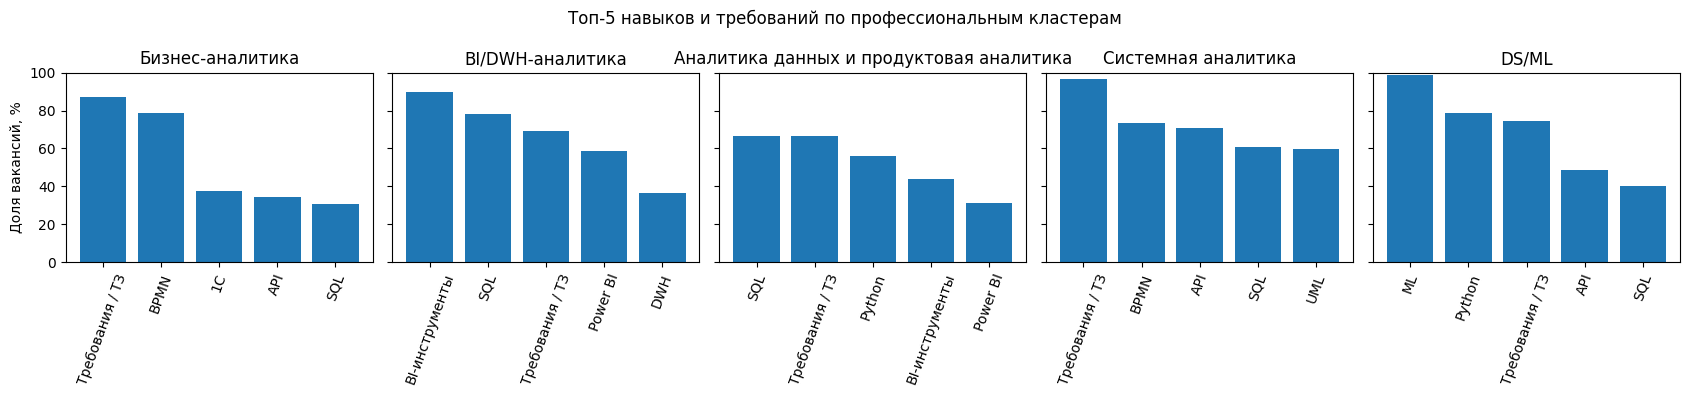

In [7]:
fig, axes = plt.subplots(1, len(cluster_order), figsize=(17, 4), sharey=True)
for ax, cluster_name in zip(axes, cluster_order):
    group = df[df['cluster_name'] == cluster_name]
    shares = group[skill_columns].fillna(0).mean().sort_values(ascending=False).head(5)
    ax.bar([skill_names[x] for x in shares.index], shares.values * 100)
    ax.set_title(cluster_name)
    ax.tick_params(axis='x', rotation=70)
    ax.set_ylim(0, 100)
axes[0].set_ylabel('Доля вакансий, %')
fig.suptitle('Топ-5 навыков и требований по профессиональным кластерам')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_3_2_2_top_skills_by_professional_cluster.png', dpi=200)
plt.show()

## 6. Качественные выводы по кластерам

In [8]:
cluster_interpretation = []
for cluster_name in cluster_order:
    group = df[df['cluster_name'] == cluster_name]
    skills = ', '.join(top_skills[top_skills['Кластер'] == cluster_name].head(4)['Навык / требование'])
    median_salary = group['salary_mid'].median()
    if median_salary >= 190000:
        salary_level = 'высокий уровень зарплат'
    elif median_salary >= 150000:
        salary_level = 'средне-высокий уровень зарплат'
    else:
        salary_level = 'умеренный уровень зарплат'
    cluster_interpretation.append([cluster_name, len(group), round(median_salary, 2), salary_level, skills])

cluster_interpretation = pd.DataFrame(
    cluster_interpretation,
    columns=['Кластер', 'Количество вакансий', 'Медианная зарплата, руб.', 'Общая характеристика зарплат', 'Основные признаки']
)
cluster_interpretation

,Кластер,Количество вакансий,"Медианная зарплата, руб.",Общая характеристика зарплат,Основные признаки
0,Бизнес-аналитика,168,140000.0,умеренный уровень зарплат,"Требования / ТЗ, BPMN, 1C, API"
1,BI/DWH-аналитика,68,149712.5,умеренный уровень зарплат,"BI-инструменты, SQL, Требования / ТЗ, Power BI"
2,Аналитика данных и продуктовая аналитика,132,130000.0,умеренный уровень зарплат,"SQL, Требования / ТЗ, Python, BI-инструменты"
3,Системная аналитика,248,182000.0,средне-высокий уровень зарплат,"Требования / ТЗ, BPMN, API, SQL"
4,DS/ML,70,200000.0,высокий уровень зарплат,"ML, Python, Требования / ТЗ, API"


## 7. Проверка нормальности зарплаты внутри кластеров

In [9]:
def lilliefors_test(sample, simulations=1500, random_state=42):
    x = np.asarray(sample, dtype=float)
    x = x[~np.isnan(x)]
    n = len(x)
    rng = np.random.default_rng(random_state + n)
    mean = x.mean()
    std = x.std(ddof=1)
    sorted_x = np.sort(x)
    ecdf = np.arange(1, n + 1) / n
    cdf = stats.norm.cdf(sorted_x, loc=mean, scale=std)
    d_obs = np.max(np.maximum(np.abs(ecdf - cdf), np.abs((np.arange(n) / n) - cdf)))
    simulated_d = []
    for _ in range(simulations):
        z = rng.normal(size=n)
        z_mean = z.mean()
        z_std = z.std(ddof=1)
        z_sorted = np.sort(z)
        z_ecdf = np.arange(1, n + 1) / n
        z_cdf = stats.norm.cdf(z_sorted, loc=z_mean, scale=z_std)
        simulated_d.append(np.max(np.maximum(np.abs(z_ecdf - z_cdf), np.abs((np.arange(n) / n) - z_cdf))))
    p_value = np.mean(np.asarray(simulated_d) >= d_obs)
    return d_obs, p_value

def format_p(p_value):
    return '< 0,01' if p_value < 0.01 else round(float(p_value), 3)

normality_rows = []
for cluster_name in cluster_order:
    salary = df[df['cluster_name'] == cluster_name]['salary_mid']
    shapiro_stat, shapiro_p = stats.shapiro(salary)
    jb_stat, jb_p = stats.jarque_bera(salary)
    lillie_stat, lillie_p = lilliefors_test(salary)
    is_normal = (shapiro_p >= 0.05) and (jb_p >= 0.05) and (lillie_p >= 0.05)
    normality_rows.append([
        cluster_name,
        len(salary),
        round(shapiro_stat, 3), format_p(shapiro_p),
        round(jb_stat, 3), format_p(jb_p),
        round(lillie_stat, 3), format_p(lillie_p),
        'нормальное' if is_normal else 'не нормальное',
    ])

cluster_normality = pd.DataFrame(
    normality_rows,
    columns=[
        'Кластер', 'Количество',
        'Шапиро-Уилка: статистика', 'Шапиро-Уилка: p-значение',
        'Жарка-Бера: статистика', 'Жарка-Бера: p-значение',
        'Лиллифорса: статистика', 'Лиллифорса: p-значение',
        'Вывод'
    ]
)
cluster_normality

,Кластер,Количество,Шапиро-Уилка: статистика,Шапиро-Уилка: p-значение,Жарка-Бера: статистика,Жарка-Бера: p-значение,Лиллифорса: статистика,Лиллифорса: p-значение,Вывод
0,Бизнес-аналитика,168,0.934,"< 0,01",20.181,"< 0,01",0.133,"< 0,01",не нормальное
1,BI/DWH-аналитика,68,0.957,0.02,4.191,0.123,0.129,"< 0,01",не нормальное
2,Аналитика данных и продуктовая аналитика,132,0.888,"< 0,01",94.037,"< 0,01",0.126,"< 0,01",не нормальное
3,Системная аналитика,248,0.964,"< 0,01",9.650,"< 0,01",0.068,"< 0,01",не нормальное
4,DS/ML,70,0.885,"< 0,01",58.408,"< 0,01",0.154,"< 0,01",не нормальное


## 8. Диаграмма связи зарплаты и опыта внутри кластеров

Для предварительной визуальной проверки используется связь `salary_mid` с уровнем требуемого опыта. Опыт закодирован как порядковый признак: `0` — нет опыта, `1` — от 1 года до 3 лет, `2` — от 3 до 6 лет, `3` — более 6 лет. Поэтому график показывает направление связи, но не рассматривается как строгая проверка линейной зависимости. Основная статистическая проверка связи опыта с зарплатой выполняется ниже с помощью коэффициента Спирмена.

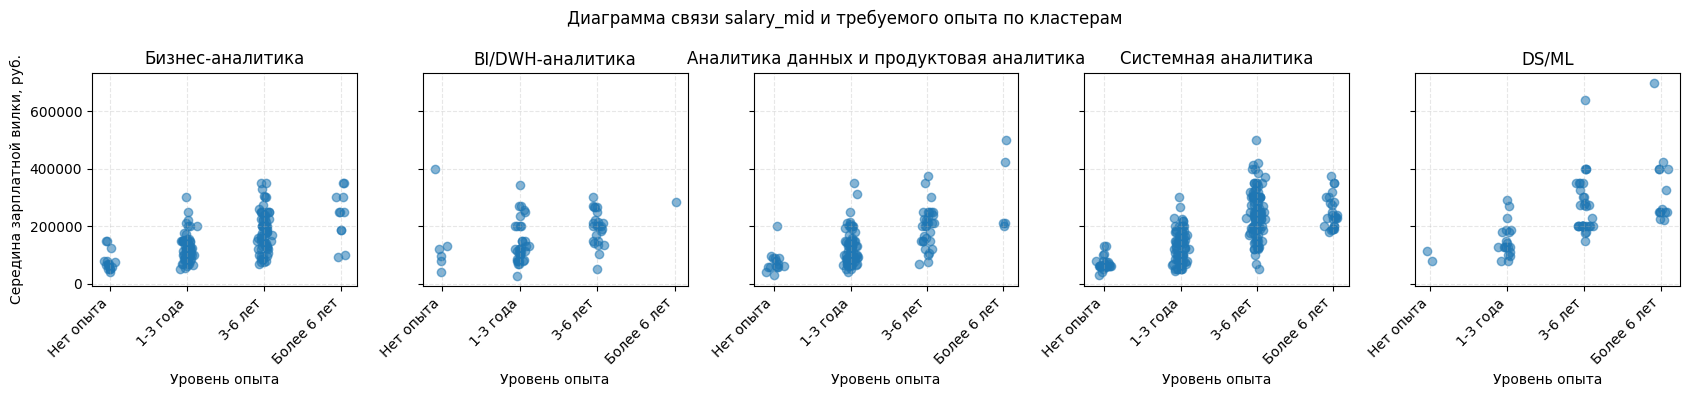

In [10]:
experience_order = {
    'Нет опыта': 0,
    'От 1 года до 3 лет': 1,
    'От 3 до 6 лет': 2,
    'Более 6 лет': 3,
}
experience_labels = {
    0: 'Нет опыта',
    1: '1-3 года',
    2: '3-6 лет',
    3: 'Более 6 лет',
}

df['experience_level'] = df['experience_name'].map(experience_order)
experience_df = df.dropna(subset=['experience_level', 'salary_mid']).copy()

rng = np.random.default_rng(42)
fig, axes = plt.subplots(1, len(cluster_order), figsize=(17, 4), sharey=True)
for ax, cluster_name in zip(axes, cluster_order):
    group = experience_df[experience_df['cluster_name'] == cluster_name]
    x = group['experience_level'].to_numpy(dtype=float)
    # Небольшой сдвиг нужен только чтобы точки с одинаковым уровнем опыта не накладывались друг на друга.
    x_jitter = x + rng.normal(0, 0.045, size=len(x))
    ax.scatter(x_jitter, group['salary_mid'], alpha=0.55)
    ax.set_title(cluster_name)
    ax.set_xlabel('Уровень опыта')
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels([experience_labels[i] for i in [0, 1, 2, 3]], rotation=45, ha='right')
    ax.grid(True, linestyle='--', alpha=0.3)
axes[0].set_ylabel('Середина зарплатной вилки, руб.')
fig.suptitle('Диаграмма связи salary_mid и требуемого опыта по кластерам')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_3_2_3_salary_experience_relation_by_cluster.png', dpi=200)
plt.show()

### Предварительный вывод по диаграмме связи

Опыт является порядковым признаком, поэтому точки расположены по четырем категориям опыта. Небольшой горизонтальный сдвиг добавлен только для читаемости графика. Диаграмма используется как предварительная визуальная проверка направления связи, а статистическая проверка выполняется ниже с помощью коэффициента Спирмена.

In [11]:
experience_relation_rows = []
for cluster_name in cluster_order:
    group = experience_df[experience_df['cluster_name'] == cluster_name]
    if group['experience_level'].nunique() > 1:
        r, p_value = stats.spearmanr(group['experience_level'], group['salary_mid'])
        if r >= 0.5:
            relation = 'заметная положительная связь'
        elif r >= 0.3:
            relation = 'умеренная положительная связь'
        elif r > 0:
            relation = 'слабая положительная связь'
        else:
            relation = 'связь не выражена'
        experience_relation_rows.append([cluster_name, len(group), round(r, 3), format_p(p_value), relation])

experience_relation_conclusions = pd.DataFrame(
    experience_relation_rows,
    columns=['Кластер', 'Количество наблюдений', 'Спирмен r', 'p-значение', 'Предварительный вывод']
)
experience_relation_conclusions

,Кластер,Количество наблюдений,Спирмен r,p-значение,Предварительный вывод
0,Бизнес-аналитика,168,0.568,"< 0,01",заметная положительная связь
1,BI/DWH-аналитика,68,0.435,"< 0,01",умеренная положительная связь
2,Аналитика данных и продуктовая аналитика,132,0.612,"< 0,01",заметная положительная связь
3,Системная аналитика,248,0.733,"< 0,01",заметная положительная связь
4,DS/ML,70,0.685,"< 0,01",заметная положительная связь


## 9. Подготовка признаков для проверки гипотез

In [12]:
df['tech_skill_count'] = df[['has_sql', 'has_python', 'has_bi_tools', 'has_dwh', 'has_etl', 'has_ml']].fillna(0).sum(axis=1)
df['has_technical_skills'] = (df['tech_skill_count'] > 0).astype(int)

df['is_moscow'] = (df['city_group'] == 'Москва').astype(int)
df['is_spb'] = (df['city_group'] == 'Санкт-Петербург').astype(int)
df['is_capital_city'] = df['city_group'].isin(['Москва', 'Санкт-Петербург']).astype(int)

df['is_remote'] = df['schedule_name'].fillna('').str.contains('Удал', case=False, regex=True).astype(int)
df['is_hybrid'] = df['schedule_name'].fillna('').str.contains('Гибрид', case=False, regex=True).astype(int)
df['is_flexible_format'] = ((df['is_remote'] == 1) | (df['is_hybrid'] == 1)).astype(int)

hypothesis_features = {
    'H1: технические навыки': ['has_technical_skills', 'has_sql', 'has_python', 'has_bi_tools', 'has_dwh', 'has_etl', 'has_ml'],
    'H2: опыт': ['experience_level'],
    'H3: регион': ['is_moscow', 'is_spb', 'is_capital_city'],
    'H4: формат работы': ['is_flexible_format'],
}

feature_names = {
    'has_technical_skills': 'Есть хотя бы один технический навык',
    'has_sql': 'SQL',
    'has_python': 'Python',
    'has_bi_tools': 'BI-инструменты',
    'has_dwh': 'DWH',
    'has_etl': 'ETL',
    'has_ml': 'ML',
    'experience_level': 'Уровень требуемого опыта',
    'is_moscow': 'Москва',
    'is_spb': 'Санкт-Петербург',
    'is_capital_city': 'Регион работы',
    'is_remote': 'Удаленный формат',
    'is_hybrid': 'Гибридный формат',
    'is_flexible_format': 'Формат работы',
}

print('Признаки для проверки гипотез подготовлены.')

Признаки для проверки гипотез подготовлены.


## 10. Корреляции Спирмена для проверки H1-H4

In [13]:
spearman_rows = []
for cluster_name in cluster_order:
    group = df[df['cluster_name'] == cluster_name].copy()
    for hypothesis, features in hypothesis_features.items():
        for feature in features:
            pair = group[[feature, 'salary_mid']].dropna()
            if len(pair) >= 5 and pair[feature].nunique() > 1:
                r, p_value = stats.spearmanr(pair[feature], pair['salary_mid'])
                spearman_rows.append([
                    cluster_name,
                    hypothesis,
                    feature_names[feature],
                    len(pair),
                    round(r, 3),
                    format_p(p_value),
                    'значима' if p_value < 0.05 else 'не значима',
                ])

spearman_results = pd.DataFrame(
    spearman_rows,
    columns=['Кластер', 'Гипотеза', 'Признак', 'Количество наблюдений', 'Спирмен r', 'p-значение', 'Вывод']
)
spearman_results

,Кластер,Гипотеза,Признак,Количество наблюдений,Спирмен r,p-значение,Вывод
0,Бизнес-аналитика,H1: технические навыки,Есть хотя бы один технический навык,168,0.149,0.054,не значима
1,Бизнес-аналитика,H1: технические навыки,SQL,168,0.099,0.203,не значима
2,Бизнес-аналитика,H1: технические навыки,Python,168,-0.078,0.314,не значима
3,Бизнес-аналитика,H1: технические навыки,BI-инструменты,168,0.004,0.964,не значима
4,Бизнес-аналитика,H1: технические навыки,ML,168,0.081,0.294,не значима
5,Бизнес-аналитика,H2: опыт,Уровень требуемого опыта,168,0.568,"< 0,01",значима
6,Бизнес-аналитика,H3: регион,Москва,168,0.420,"< 0,01",значима
7,Бизнес-аналитика,H3: регион,Санкт-Петербург,168,0.094,0.226,не значима
8,Бизнес-аналитика,H3: регион,Регион работы,168,0.479,"< 0,01",значима
9,Бизнес-аналитика,H4: формат работы,Формат работы,168,0.196,0.011,значима


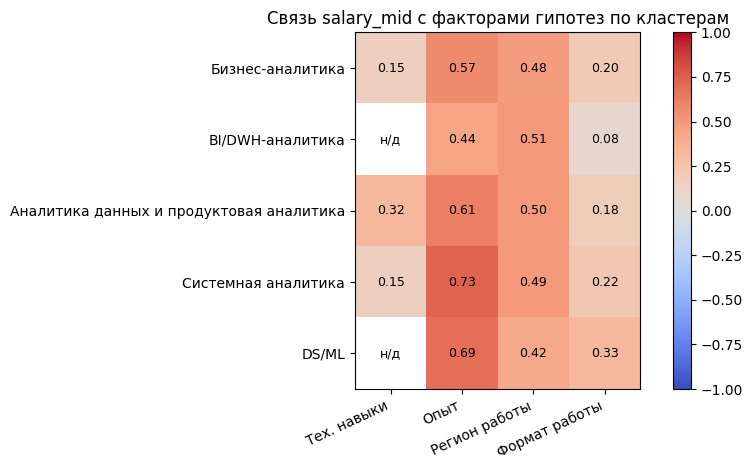

In [14]:
# Компактная тепловая карта: показываем только связь зарплаты с факторами гипотез.
# Регион и формат работы закодированы численно, но в подписи указаны содержательные названия факторов.
factor_features = ['has_technical_skills', 'experience_level', 'is_capital_city', 'is_flexible_format']
factor_labels = ['Тех. навыки', 'Опыт', 'Регион работы', 'Формат работы']

heatmap_rows = []
heatmap_values = []
for cluster_name in cluster_order:
    group = df[df['cluster_name'] == cluster_name]
    row = []
    for feature in factor_features:
        pair = group[[feature, 'salary_mid']].dropna()
        if len(pair) >= 5 and pair[feature].nunique() > 1:
            r, p_value = stats.spearmanr(pair[feature], pair['salary_mid'])
            row.append(r)
        else:
            row.append(np.nan)
    heatmap_rows.append(cluster_name)
    heatmap_values.append(row)

salary_factor_heatmap = pd.DataFrame(heatmap_values, index=heatmap_rows, columns=factor_labels)

plt.figure(figsize=(9, 4.8))
im = plt.imshow(salary_factor_heatmap, vmin=-1, vmax=1, cmap='coolwarm')
plt.xticks(range(len(factor_labels)), factor_labels, rotation=25, ha='right')
plt.yticks(range(len(heatmap_rows)), heatmap_rows)
for i in range(salary_factor_heatmap.shape[0]):
    for j in range(salary_factor_heatmap.shape[1]):
        val = salary_factor_heatmap.iloc[i, j]
        if not np.isnan(val):
            plt.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9)
        else:
            plt.text(j, i, 'н/д', ha='center', va='center', fontsize=9)
plt.colorbar(im, fraction=0.035, pad=0.04)
plt.title('Связь salary_mid с факторами гипотез по кластерам')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_3_2_4_salary_factor_heatmap_by_cluster.png', dpi=200)
plt.show()

## 11. Итоги проверки гипотез в компактном виде

In [15]:
# Компактная таблица для Word: по каждой гипотезе и кластеру оставляем главный результат.
def relation_strength(r):
    ar = abs(r)
    if ar >= 0.7:
        return 'сильная'
    if ar >= 0.5:
        return 'заметная'
    if ar >= 0.3:
        return 'умеренная'
    if ar >= 0.1:
        return 'слабая'
    return 'почти отсутствует'

hypothesis_main_feature = {
    'H1: технические навыки': 'Есть хотя бы один технический навык',
    'H2: опыт': 'Уровень требуемого опыта',
    'H3: регион': 'Регион работы',
    'H4: формат работы': 'Формат работы',
}

compact_rows = []
for cluster_name in cluster_order:
    for hypothesis, feature_name in hypothesis_main_feature.items():
        row = spearman_results[
            (spearman_results['Кластер'] == cluster_name) &
            (spearman_results['Гипотеза'] == hypothesis) &
            (spearman_results['Признак'] == feature_name)
        ]
        if len(row) == 0:
            compact_rows.append([cluster_name, hypothesis, feature_name, 'н/д', 'н/д', 'не проверялась'])
        else:
            row = row.iloc[0]
            r = row['Спирмен r']
            p_value = row['p-значение']
            if row['Вывод'] == 'значима' and r > 0:
                conclusion = f'подтверждается, связь {relation_strength(r)} положительная'
            elif row['Вывод'] == 'значима' and r < 0:
                conclusion = f'значимая отрицательная связь'
            else:
                conclusion = 'не подтверждается'
            compact_rows.append([cluster_name, hypothesis, feature_name, r, p_value, conclusion])

hypothesis_compact_summary = pd.DataFrame(
    compact_rows,
    columns=['Кластер', 'Гипотеза', 'Основной признак', 'Спирмен r', 'p-значение', 'Вывод']
)
hypothesis_compact_summary

,Кластер,Гипотеза,Основной признак,Спирмен r,p-значение,Вывод
0,Бизнес-аналитика,H1: технические навыки,Есть хотя бы один технический навык,0.149,0.054,не подтверждается
1,Бизнес-аналитика,H2: опыт,Уровень требуемого опыта,0.568,"< 0,01","подтверждается, связь заметная положительная"
2,Бизнес-аналитика,H3: регион,Регион работы,0.479,"< 0,01","подтверждается, связь умеренная положительная"
3,Бизнес-аналитика,H4: формат работы,Формат работы,0.196,0.011,"подтверждается, связь слабая положительная"
4,BI/DWH-аналитика,H1: технические навыки,Есть хотя бы один технический навык,н/д,н/д,не проверялась
5,BI/DWH-аналитика,H2: опыт,Уровень требуемого опыта,0.435,"< 0,01","подтверждается, связь умеренная положительная"
6,BI/DWH-аналитика,H3: регион,Регион работы,0.505,"< 0,01","подтверждается, связь заметная положительная"
7,BI/DWH-аналитика,H4: формат работы,Формат работы,0.084,0.494,не подтверждается
8,Аналитика данных и продуктовая аналитика,H1: технические навыки,Есть хотя бы один технический навык,0.325,"< 0,01","подтверждается, связь умеренная положительная"
9,Аналитика данных и продуктовая аналитика,H2: опыт,Уровень требуемого опыта,0.612,"< 0,01","подтверждается, связь заметная положительная"


### Короткая итоговая таблица для вставки в Word

В таблицу для Word целесообразно включать не все 20 строк по кластерам, а общий вывод по каждой гипотезе. Подробная таблица выше остается в блокноте как расчетная расшифровка.

In [16]:
word_summary_rows = []
for hypothesis in hypothesis_main_feature:
    subset = hypothesis_compact_summary[hypothesis_compact_summary['Гипотеза'] == hypothesis].copy()
    confirmed = subset[subset['Вывод'].astype(str).str.contains('подтверждается', regex=False)]
    not_confirmed = subset[subset['Вывод'].astype(str).str.contains('не подтверждается', regex=False)]
    not_checked = subset[subset['Вывод'].astype(str).str.contains('не проверялась', regex=False)]
    if len(confirmed) >= 3:
        result = 'в целом подтверждается'
    elif len(confirmed) > 0:
        result = 'частично подтверждается'
    else:
        result = 'не подтверждается'
    details = []
    if len(confirmed) > 0:
        details.append('подтверждается в кластерах: ' + ', '.join(confirmed['Кластер'].tolist()))
    if len(not_confirmed) > 0:
        details.append('не подтверждается: ' + ', '.join(not_confirmed['Кластер'].tolist()))
    if len(not_checked) > 0:
        details.append('не проверялась: ' + ', '.join(not_checked['Кластер'].tolist()))
    word_summary_rows.append([hypothesis, hypothesis_main_feature[hypothesis], result, '; '.join(details)])

hypothesis_word_summary = pd.DataFrame(
    word_summary_rows,
    columns=['Гипотеза', 'Основной признак', 'Итог', 'Краткое основание']
)
hypothesis_word_summary

,Гипотеза,Основной признак,Итог,Краткое основание
0,H1: технические навыки,Есть хотя бы один технический навык,в целом подтверждается,"подтверждается в кластерах: Бизнес-аналитика, ..."
1,H2: опыт,Уровень требуемого опыта,в целом подтверждается,"подтверждается в кластерах: Бизнес-аналитика, ..."
2,H3: регион,Регион работы,в целом подтверждается,"подтверждается в кластерах: Бизнес-аналитика, ..."
3,H4: формат работы,Формат работы,в целом подтверждается,"подтверждается в кластерах: Бизнес-аналитика, ..."


## 12. Сохранение данных с кластерами

In [17]:
OUTPUT_PATH = Path('vacancies_with_professional_clusters.csv')
df.to_csv(OUTPUT_PATH, index=False)
print('Файл сохранен:', OUTPUT_PATH)

Файл сохранен: vacancies_with_professional_clusters.csv


## 13. Краткие итоги для параграфа 3.2

In [18]:
summary_3_2 = pd.DataFrame({
    'Показатель': [
        'Количество вакансий в кластеризации',
        'Количество кластеров',
        'Основание кластеризации',
        'Использовалась ли зарплата для формирования кластеров',
        'Почему объединены аналитика данных и продуктовая аналитика',
        'Самый крупный кластер',
        'Кластер с наибольшей медианной зарплатой',
        'Диаграмма связи внутри кластеров',
        'Почему Пирсон не используется для гипотез',
        'Основной метод проверки гипотез',
    ],
    'Значение': [
        len(df),
        len(cluster_order),
        'профессиональная специализация вакансии',
        'нет',
        'вакансий продуктовых аналитиков мало, а требования близки к аналитике данных',
        cluster_counts.sort_values('Количество вакансий', ascending=False).iloc[0]['cluster_name'],
        cluster_salary.sort_values('Медиана', ascending=False).iloc[0]['Название кластера'],
        'salary_mid и уровень требуемого опыта',
        'нет независимых непрерывных количественных факторов зарплаты',
        'коэффициент Спирмена между salary_mid и основными факторами H1-H4',
    ]
})
summary_3_2

,Показатель,Значение
0,Количество вакансий в кластеризации,686
1,Количество кластеров,5
2,Основание кластеризации,профессиональная специализация вакансии
3,Использовалась ли зарплата для формирования кл...,нет
4,Почему объединены аналитика данных и продуктов...,"вакансий продуктовых аналитиков мало, а требов..."
5,Самый крупный кластер,Системная аналитика
6,Кластер с наибольшей медианной зарплатой,DS/ML
7,Диаграмма связи внутри кластеров,salary_mid и уровень требуемого опыта
8,Почему Пирсон не используется для гипотез,нет независимых непрерывных количественных фак...
9,Основной метод проверки гипотез,коэффициент Спирмена между salary_mid и основн...
